# Comprehensive EDA — MetaHarmonizer Metadata Analysis

## Exploratory Data Analysis of Raw Clinical Metadata

**Sections Covered:**
1. Dataset Overview
2. Data Types Analysis
3. Missing Data Analysis
4. Duplicate & Integrity Checks
5. Numerical Data Analysis
6. Categorical Data Analysis
7. Feature Sparsity Analysis
8. Column Name / Schema Analysis
9. Value Standardization Analysis
10. Column Importance / Usability
11. Relationship Analysis
12. Visualization

**Input files:**
- `../metadata_samples/new_meta.csv` — Raw clinical metadata (main target)
- `../metadata_samples/curated_meta.csv` — Standardized gold-standard metadata

**Output:** Deep understanding of data heterogeneity, quality issues, and harmonization opportunities for SchemaMapEngine

## 1. Setup & Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("Libraries imported successfully")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")

Libraries imported successfully
  pandas  2.3.3
  numpy   2.2.6
  seaborn 0.13.2


In [9]:
metadata_dir = Path("../metadata_samples")

df_curated = pd.read_csv(metadata_dir / "curated_meta.csv")
df_new     = pd.read_csv(metadata_dir / "new_meta.csv")

# Work primarily on the raw metadata for the deep EDA
df = df_new.copy()

print(f"Curated metadata : {df_curated.shape[0]:,} rows  x  {df_curated.shape[1]} columns")
print(f"Raw metadata     : {df.shape[0]:,} rows  x  {df.shape[1]} columns")

Curated metadata : 21,881 rows  x  37 columns
Raw metadata     : 707 rows  x  141 columns


---
## Section 1 — Dataset Overview

Basic structure, size, memory footprint, and a quick visual preview of both datasets.

In [10]:
def section_header(title):
    print("\n" + "=" * 70)
    print(f"  {title}")
    print("=" * 70)

section_header("SECTION 1: DATASET OVERVIEW")

for label, d in [("RAW (new_meta)", df), ("CURATED (curated_meta)", df_curated)]:
    mem_mb = d.memory_usage(deep=True).sum() / 1024**2
    print(f"\n--- {label} ---")
    print(f"  Rows              : {d.shape[0]:,}")
    print(f"  Columns           : {d.shape[1]}")
    print(f"  Memory usage      : {mem_mb:.2f} MB")
    print(f"  Total cells       : {d.size:,}")
    print(f"  Non-null cells    : {d.count().sum():,}")
    print(f"  Null cells        : {d.isnull().sum().sum():,}  ({d.isnull().sum().sum()/d.size*100:.1f}%)")


  SECTION 1: DATASET OVERVIEW

--- RAW (new_meta) ---
  Rows              : 707
  Columns           : 141
  Memory usage      : 1.52 MB
  Total cells       : 99,687
  Non-null cells    : 16,335
  Null cells        : 83,352  (83.6%)

--- CURATED (curated_meta) ---
  Rows              : 21,881
  Columns           : 37
  Memory usage      : 38.76 MB
  Total cells       : 809,597
  Non-null cells    : 464,612
  Null cells        : 344,985  (42.6%)


In [11]:
print("--- RAW METADATA: Column names (all) ---")
cols = df.columns.tolist()
for i, col in enumerate(cols, 1):
    print(f"  {i:3d}. {col}")

print(f"\nTotal: {len(cols)} columns")

--- RAW METADATA: Column names (all) ---
    1. study_name
    2. sample_id
    3. subject_id
    4. body_site
    5. antibiotics_current_use
    6. study_condition
    7. disease
    8. age
    9. infant_age
   10. age_category
   11. gender
   12. country
   13. non_westernized
   14. sequencing_platform
   15. DNA_extraction_kit
   16. PMID
   17. number_reads
   18. number_bases
   19. minimum_read_length
   20. median_read_length
   21. NCBI_accession
   22. pregnant
   23. lactating
   24. curator
   25. BMI
   26. family
   27. treatment
   28. days_from_first_collection
   29. family_role
   30. born_method
   31. feeding_practice
   32. location
   33. diet
   34. travel_destination
   35. visit_number
   36. premature
   37. birth_weight
   38. gestational_age
   39. antibiotics_family
   40. disease_subtype
   41. days_after_onset
   42. creatine
   43. albumine
   44. hscrp
   45. ESR
   46. ast
   47. alt
   48. globulin
   49. urea_nitrogen
   50. BASDAI
   51. BASFI
   5

In [12]:
print("--- RAW METADATA: Head (first 5 rows, first 20 columns) ---")
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 25)
print(df.iloc[:5, :20].to_string())

print("\n--- RAW METADATA: Tail (last 5 rows, first 20 columns) ---")
print(df.iloc[-5:, :20].to_string())

--- RAW METADATA: Head (first 5 rows, first 20 columns) ---
        study_name sample_id           subject_id body_site antibiotics_current_use study_condition  disease   age  infant_age age_category  gender country non_westernized sequencing_platform DNA_extraction_kit      PMID  number_reads  number_bases  minimum_read_length  median_read_length
0  HanniganGD_2017  MG100208  HanniganGD_2017_A29     stool                      no         adenoma  adenoma  45.0         NaN        adult  female     CAN              no       IlluminaHiSeq              MoBio  30459201       6133350     763336051                   75                 126
1  HanniganGD_2017  MG100207  HanniganGD_2017_A28     stool                      no         adenoma  adenoma  50.0         NaN        adult    male     CAN              no       IlluminaHiSeq              MoBio  30459201       9320348    1161633690                   75                 126
2  HanniganGD_2017  MG100206  HanniganGD_2017_A27     stool           

---
## Section 2 — Data Types Analysis

Identify numeric, categorical, datetime, and mixed-type columns. Fix obvious type mismatches.

In [13]:
section_header("SECTION 2: DATA TYPES ANALYSIS")

numeric_cols  = df.select_dtypes(include=['int64','float64']).columns.tolist()
object_cols   = df.select_dtypes(include=['object']).columns.tolist()
bool_cols     = df.select_dtypes(include=['bool']).columns.tolist()

# Detect datetime-like columns
dt_cols = []
for col in object_cols:
    sample = df[col].dropna().head(30)
    try:
        parsed = pd.to_datetime(sample, errors='coerce', infer_datetime_format=True)
        if parsed.notna().mean() > 0.6:
            dt_cols.append(col)
    except Exception:
        pass

# Detect mixed-type columns (object column that contains both numbers and strings)
mixed_cols = []
for col in object_cols:
    sample = df[col].dropna()
    if len(sample) == 0:
        continue
    num_like = pd.to_numeric(sample, errors='coerce').notna().mean()
    if 0.05 < num_like < 0.95:
        mixed_cols.append((col, f"{num_like*100:.0f}% numeric-like"))

print(f"  Numeric columns    : {len(numeric_cols)}")
print(f"  Object/String cols : {len(object_cols)}")
print(f"  Boolean columns    : {len(bool_cols)}")
print(f"  Datetime-like cols : {len(dt_cols)}")
print(f"  Mixed-type cols    : {len(mixed_cols)}")

if dt_cols:
    print(f"\n  Datetime-like columns: {dt_cols}")

if mixed_cols:
    print(f"\n  Mixed-type column details:")
    for col, note in mixed_cols[:10]:
        print(f"    {col}: {note}")

print(f"\n  Numeric examples   : {numeric_cols[:8]}")
print(f"  Object examples    : {object_cols[:8]}")


  SECTION 2: DATA TYPES ANALYSIS
  Numeric columns    : 117
  Object/String cols : 24
  Boolean columns    : 0
  Datetime-like cols : 0
  Mixed-type cols    : 0

  Numeric examples   : ['age', 'infant_age', 'PMID', 'number_reads', 'number_bases', 'minimum_read_length', 'median_read_length', 'lactating']
  Object examples    : ['study_name', 'sample_id', 'subject_id', 'body_site', 'antibiotics_current_use', 'study_condition', 'disease', 'age_category']


In [14]:
# Attempt to coerce object columns that look numeric
fixed = {}
for col in object_cols:
    sample = df[col].dropna()
    if len(sample) == 0:
        continue
    coerced = pd.to_numeric(sample, errors='coerce')
    if coerced.notna().mean() > 0.9:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        fixed[col] = str(df[col].dtype)

if fixed:
    print(f"Type-fixed columns ({len(fixed)}):")
    for col, new_type in fixed.items():
        print(f"  {col} -> {new_type}")
else:
    print("No obvious type corrections needed.")

No obvious type corrections needed.


---
## Section 3 — Missing Data Analysis

Missing values per column, percentages, patterns, and thresholds critical for mapping.

In [15]:
section_header("SECTION 3: MISSING DATA ANALYSIS")

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

miss_df = pd.DataFrame({
    'column': missing_count.index,
    'missing_count': missing_count.values,
    'missing_pct': missing_pct.values
}).sort_values('missing_pct', ascending=False).reset_index(drop=True)

# Thresholds
no_missing    = miss_df[miss_df['missing_pct'] == 0]
low_missing   = miss_df[(miss_df['missing_pct'] > 0) & (miss_df['missing_pct'] < 30)]
med_missing   = miss_df[(miss_df['missing_pct'] >= 30) & (miss_df['missing_pct'] < 70)]
high_missing  = miss_df[(miss_df['missing_pct'] >= 70) & (miss_df['missing_pct'] < 100)]
all_missing   = miss_df[miss_df['missing_pct'] == 100]

print(f"  No missing (0%)         : {len(no_missing)} columns")
print(f"  Low missing (<30%)      : {len(low_missing)} columns")
print(f"  Medium missing (30-70%) : {len(med_missing)} columns")
print(f"  High missing (>70%)     : {len(high_missing)} columns")
print(f"  Completely empty (100%) : {len(all_missing)} columns")

print(f"\n  Top 30 most-missing columns:")
print(miss_df.head(30).to_string(index=False))

print(f"\n  Missing per row — stats:")
row_missing = df.isnull().sum(axis=1)
print(f"    Min  : {row_missing.min()}")
print(f"    Max  : {row_missing.max()}")
print(f"    Mean : {row_missing.mean():.1f}")
print(f"    Rows with >50% missing : {(row_missing > df.shape[1]*0.5).sum():,}")


  SECTION 3: MISSING DATA ANALYSIS
  No missing (0%)         : 18 columns
  Low missing (<30%)      : 0 columns
  Medium missing (30-70%) : 7 columns
  High missing (>70%)     : 12 columns
  Completely empty (100%) : 104 columns

  Top 30 most-missing columns:
                  column  missing_count  missing_pct
                  RECIST            707        100.0
                    diet            707        100.0
               premature            707        100.0
        days_after_onset            707        100.0
      antibiotics_family            707        100.0
                   hscrp            707        100.0
                     ESR            707        100.0
            visit_number            707        100.0
      travel_destination            707        100.0
                creatine            707        100.0
                albumine            707        100.0
               lactating            707        100.0
               treatment            707        10

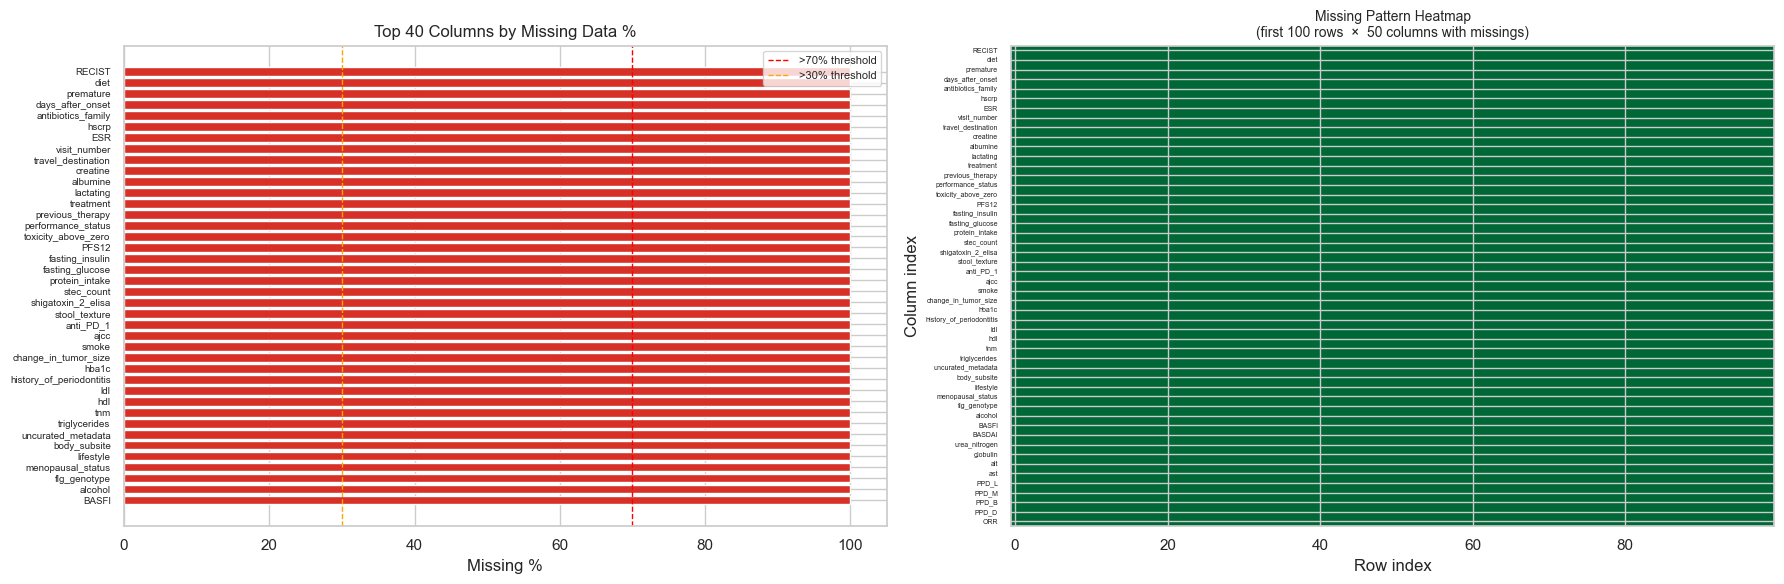

Plot saved: missing_data_analysis.png


In [16]:
# Missing data visualization: bar chart (top 40 columns) + heatmap sample
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart — top 40 columns by missing %
top40 = miss_df.head(40)
colors = ['#d73027' if p > 70 else '#fc8d59' if p > 30 else '#fee090'
          for p in top40['missing_pct']]
axes[0].barh(top40['column'][::-1], top40['missing_pct'][::-1], color=colors[::-1])
axes[0].axvline(70, color='red',    linestyle='--', linewidth=1, label='>70% threshold')
axes[0].axvline(30, color='orange', linestyle='--', linewidth=1, label='>30% threshold')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Top 40 Columns by Missing Data %')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=7)

# Heatmap — sample of rows vs columns (first 50 cols that have some missing)
cols_with_missing = miss_df[miss_df['missing_pct'] > 0]['column'].head(50).tolist()
sample_rows = min(100, len(df))
heatmap_data = df[cols_with_missing].iloc[:sample_rows].isnull().astype(int)
axes[1].imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn_r', interpolation='none')
axes[1].set_title(f'Missing Pattern Heatmap\n(first {sample_rows} rows  ×  50 columns with missings)', fontsize=10)
axes[1].set_xlabel('Row index')
axes[1].set_ylabel('Column index')
axes[1].set_yticks(range(len(cols_with_missing)))
axes[1].set_yticklabels(cols_with_missing, fontsize=5)

plt.tight_layout()
plt.savefig('missing_data_analysis.png', bbox_inches='tight', dpi=120)
plt.show()
print("Plot saved: missing_data_analysis.png")

---
## Section 4 — Duplicate & Integrity Checks

Detect duplicate rows/IDs, inconsistent values, invalid ranges, empty and constant columns.

In [17]:
section_header("SECTION 4: DUPLICATE & INTEGRITY CHECKS")

# Duplicate rows
dup_rows = df.duplicated().sum()
print(f"  Duplicate rows      : {dup_rows} ({dup_rows/len(df)*100:.2f}%)")

# Duplicate IDs (look for ID-like columns)
id_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['id','sample','subject','patient','accession','sampleid','sample_id','subject_id'])]
print(f"\n  ID-like columns found: {id_cols}")
for col in id_cols[:5]:
    n_unique = df[col].nunique()
    n_dup    = df.duplicated(subset=[col]).sum()
    print(f"    {col}: {n_unique} unique / {n_dup} duplicate values")

# Constant columns (single unique non-null value or all null)
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print(f"\n  Constant/empty columns ({len(constant_cols)}):")
for c in constant_cols:
    val = df[c].dropna().unique()
    print(f"    {c}: {val if len(val) > 0 else '[all null]'}")

# Invalid numeric ranges (e.g. negative ages, percentages > 100)
age_cols = [c for c in df.columns if 'age' in c.lower() and df[c].dtype in ['float64','int64']]
for col in age_cols:
    neg = (df[col] < 0).sum()
    extreme = (df[col] > 150).sum()
    if neg > 0 or extreme > 0:
        print(f"\n  Invalid range in '{col}': {neg} negative values, {extreme} values > 150")


  SECTION 4: DUPLICATE & INTEGRITY CHECKS
  Duplicate rows      : 0 (0.00%)

  ID-like columns found: ['sample_id', 'subject_id', 'PMID', 'NCBI_accession', 'triglycerides', 'dental_sample_type', 'c_peptide', 'fmt_id']
    sample_id: 707 unique / 0 duplicate values
    subject_id: 516 unique / 191 duplicate values
    PMID: 3 unique / 704 duplicate values
    NCBI_accession: 352 unique / 354 duplicate values
    triglycerides: 0 unique / 706 duplicate values

  Constant/empty columns (109):
    body_site: ['stool']
    antibiotics_current_use: ['no']
    non_westernized: ['no']
    sequencing_platform: ['IlluminaHiSeq']
    lactating: [all null]
    treatment: [all null]
    diet: [all null]
    travel_destination: [all null]
    visit_number: [all null]
    premature: [all null]
    antibiotics_family: [all null]
    days_after_onset: [all null]
    creatine: [all null]
    albumine: [all null]
    hscrp: [all null]
    ESR: [all null]
    ast: [all null]
    alt: [all null]
    globu

---
## Section 5 — Numerical Data Analysis

Summary statistics, distributions, outlier detection, skewness/kurtosis, and correlation.

In [18]:
section_header("SECTION 5: NUMERICAL DATA ANALYSIS")

num_df = df.select_dtypes(include=['int64','float64'])
print(f"  Numeric columns: {num_df.shape[1]}")

if num_df.shape[1] == 0:
    print("  No numeric columns to analyse.")
else:
    desc = num_df.describe().T
    desc['skewness']  = num_df.skew()
    desc['kurtosis']  = num_df.kurtosis()
    desc['iqr']       = desc['75%'] - desc['25%']
    desc['cv_%']      = (desc['std'] / desc['mean'].replace(0, np.nan) * 100).round(1)

    print("\n  Summary Statistics:")
    pd.set_option('display.float_format', '{:.3f}'.format)
    print(desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis','cv_%']].to_string())

    # Outlier detection (IQR method)
    print("\n  Outlier counts (IQR method, factor=1.5):")
    outlier_info = []
    for col in num_df.columns:
        series = num_df[col].dropna()
        if len(series) < 5:
            continue
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
        if outliers > 0:
            outlier_info.append({'column': col, 'outliers': outliers,
                                  'pct': f"{outliers/len(series)*100:.1f}%"})
    oi_df = pd.DataFrame(outlier_info).sort_values('outliers', ascending=False)
    if len(oi_df) > 0:
        print(oi_df.to_string(index=False))
    else:
        print("  No outliers detected.")


  SECTION 5: NUMERICAL DATA ANALYSIS
  Numeric columns: 117

  Summary Statistics:
                                     count           mean            std          min            25%            50%            75%            max  skewness  kurtosis   cv_%
age                                 81.000         58.580         10.793       35.000         51.000         59.000         65.000         88.000     0.166    -0.176 18.400
infant_age                         155.000         39.858         32.105        0.000         14.000         30.000         60.000         90.000     0.375    -1.254 80.500
PMID                               707.000   30338360.436     267821.862 30001517.000   30001517.000   30567928.000   30567928.000   30567928.000    -0.438    -1.766  0.900
number_reads                       707.000   23644491.416   12319298.912    17146.000   14631833.000   22911696.000   33073995.000   61282548.000     0.159    -0.543 52.100
number_bases                       707.000 23412048

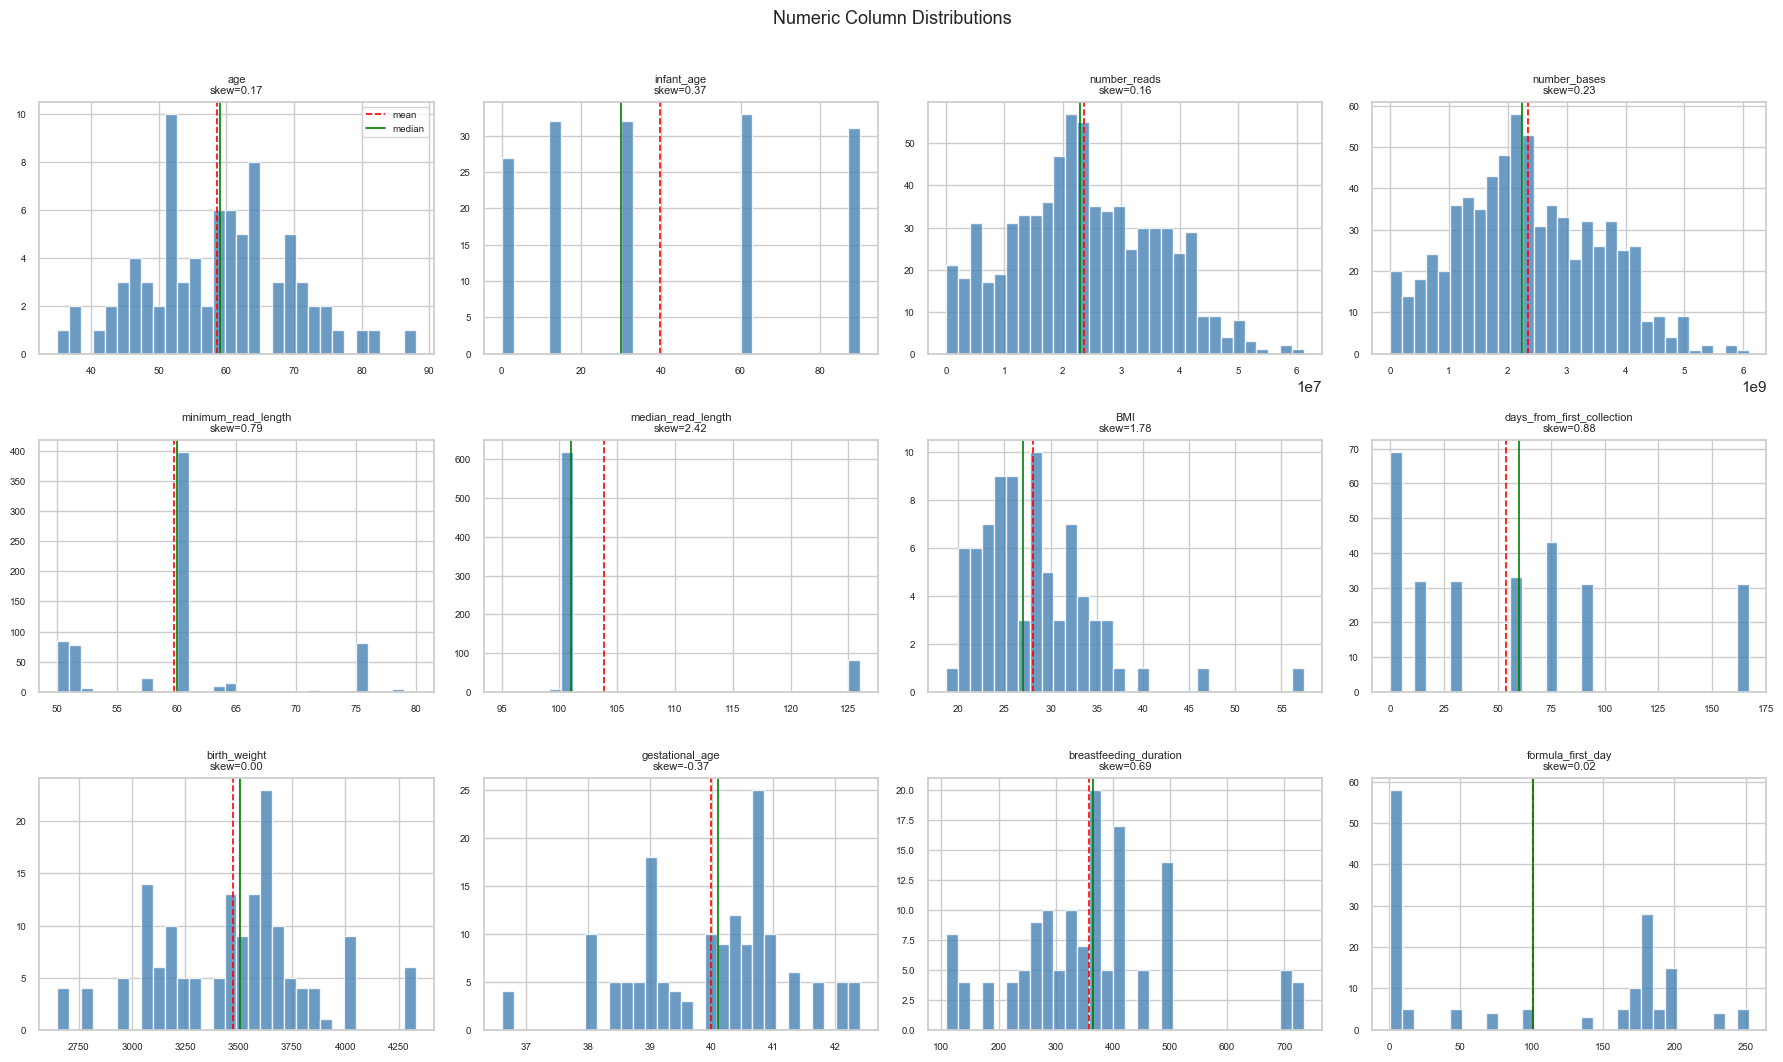

Plot saved: numeric_distributions.png


In [19]:
# Distribution histograms for numeric columns
num_df = df.select_dtypes(include=['int64','float64'])
num_cols_plot = [c for c in num_df.columns if num_df[c].dropna().nunique() > 3][:16]

if num_cols_plot:
    n_rows = (len(num_cols_plot) + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(num_cols_plot):
        data = num_df[col].dropna()
        axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label='mean')
        axes[i].axvline(data.median(), color='green',  linestyle='-',  linewidth=1.2, label='median')
        axes[i].set_title(f"{col}\nskew={data.skew():.2f}", fontsize=8)
        axes[i].tick_params(labelsize=7)
        if i == 0:
            axes[i].legend(fontsize=7)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Column Distributions', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('numeric_distributions.png', bbox_inches='tight', dpi=100)
    plt.show()
    print("Plot saved: numeric_distributions.png")
else:
    print("Not enough numeric columns with variance to plot.")

---
## Section 6 — Categorical Data Analysis

Unique values, frequency distributions, imbalance, synonym detection, and rare categories.

In [20]:
section_header("SECTION 6: CATEGORICAL DATA ANALYSIS")

cat_df = df.select_dtypes(include=['object'])
print(f"  Categorical columns: {cat_df.shape[1]}\n")

cat_stats = []
for col in cat_df.columns:
    series = cat_df[col].dropna()
    n_unique = series.nunique()
    top_val  = series.value_counts().idxmax() if len(series) > 0 else None
    top_pct  = series.value_counts().iloc[0] / len(series) * 100 if len(series) > 0 else 0
    rare     = (series.value_counts() == 1).sum()
    cat_stats.append({
        'column': col,
        'unique_values': n_unique,
        'top_value': str(top_val)[:25],
        'top_pct': f"{top_pct:.1f}%",
        'rare_categories': rare,
        'non_null': len(series)
    })

cat_stats_df = pd.DataFrame(cat_stats).sort_values('unique_values', ascending=False)
print("  Categorical column summary (top 30 by cardinality):")
print(cat_stats_df.head(30).to_string(index=False))


  SECTION 6: CATEGORICAL DATA ANALYSIS
  Categorical columns: 24

  Categorical column summary (top 30 by cardinality):
                 column  unique_values                 top_value top_pct  rare_categories  non_null
              sample_id            707                   G102216    0.1%              707       707
             subject_id            516                    M0084C    0.7%              440       707
         NCBI_accession            352                SRR7281027    0.3%              352       352
                 family             80      YassourM_2018_M0018C    1.8%                4       271
                country              4                       NLD   50.2%                0       707
               location              4                   Toronto   33.3%                0        81
                disease              4                       IBD   50.2%                0       707
        study_condition              4                       IBD   50.2%       

In [21]:
# Synonym detection: look for near-identical values (case/whitespace variants)
KNOWN_SYNONYM_GROUPS = {
    'sex/gender': ['male','female','m','f','1','0','2','unknown','other','na','nan'],
    'yes/no':     ['yes','no','y','n','true','false','1','0','positive','negative'],
    'race':       ['white','caucasian','black','african american','african-american',
                   'asian','hispanic','latino','other','unknown','na'],
}

print("Synonym / value inconsistency analysis:\n")

for col in cat_df.columns:
    series = cat_df[col].dropna()
    if series.nunique() < 2 or series.nunique() > 50:
        continue
    lower_vals = series.str.strip().str.lower().unique().tolist()
    # Check if distinct cleaned values are fewer than raw unique values
    raw_unique = series.unique().tolist()
    cleaned_unique = series.str.strip().str.lower().unique().tolist()
    if len(cleaned_unique) < len(raw_unique):
        print(f"  '{col}' — raw: {len(raw_unique)} values, after case-strip: {len(cleaned_unique)} values")
        print(f"    Raw values: {sorted([str(v) for v in raw_unique])[:15]}")
        print()

print("\nKnown synonym group matches:")
for category, synonyms in KNOWN_SYNONYM_GROUPS.items():
    hits = []
    for col in cat_df.columns:
        series = cat_df[col].dropna()
        vals_lower = set(series.str.strip().str.lower().unique())
        overlap = vals_lower & set(synonyms)
        if len(overlap) >= 2:
            hits.append(f"{col} ({sorted(overlap)})")
    if hits:
        print(f"  {category}: {hits[:5]}")

Synonym / value inconsistency analysis:


Known synonym group matches:
  sex/gender: ["gender (['female', 'male'])"]
  yes/no: ["pregnant (['no', 'yes'])", "fobt (['no', 'yes'])"]


---
## Section 7 — Feature Sparsity Analysis

Identify sparse columns and rows. Critical for biomedical datasets where most fields are study-specific.

In [22]:
section_header("SECTION 7: FEATURE SPARSITY ANALYSIS")

col_fill = (df.notna().sum() / len(df) * 100).sort_values()
row_fill = (df.notna().sum(axis=1) / df.shape[1] * 100)

# Column sparsity thresholds
very_sparse = (col_fill < 10).sum()
sparse      = ((col_fill >= 10) & (col_fill < 30)).sum()
moderate    = ((col_fill >= 30) & (col_fill < 70)).sum()
dense       = (col_fill >= 70).sum()

print("  Column fill-rate distribution:")
print(f"    Very sparse (<10% filled)  : {very_sparse} columns")
print(f"    Sparse (10-30% filled)     : {sparse} columns")
print(f"    Moderate (30-70% filled)   : {moderate} columns")
print(f"    Dense (>70% filled)        : {dense} columns")

print("\n  Bottom 20 sparsest columns (lowest fill %):")
print(col_fill.head(20).rename("fill_%").to_frame().to_string())

print("\n  Top 20 densest columns (highest fill %):")
print(col_fill.tail(20).rename("fill_%").iloc[::-1].to_frame().to_string())

print(f"\n  Row fill-rate stats:")
print(f"    Mean row coverage  : {row_fill.mean():.1f}%")
print(f"    Median row coverage: {row_fill.median():.1f}%")
print(f"    Rows with <20% fill: {(row_fill < 20).sum():,}")
print(f"    Rows with >80% fill: {(row_fill > 80).sum():,}")


  SECTION 7: FEATURE SPARSITY ANALYSIS
  Column fill-rate distribution:
    Very sparse (<10% filled)  : 104 columns
    Sparse (10-30% filled)     : 12 columns
    Moderate (30-70% filled)   : 7 columns
    Dense (>70% filled)        : 18 columns

  Bottom 20 sparsest columns (lowest fill %):
                      fill_%
treatment              0.000
lactating              0.000
BASFI                  0.000
globulin               0.000
triglycerides          0.000
change_in_tumor_size   0.000
ldl                    0.000
hba1c                  0.000
body_subsite           0.000
lifestyle              0.000
menopausal_status      0.000
flg_genotype           0.000
alcohol                0.000
tnm                    0.000
uncurated_metadata     0.000
hdl                    0.000
urea_nitrogen          0.000
BASDAI                 0.000
albumine               0.000
antibiotics_family     0.000

  Top 20 densest columns (highest fill %):
                     fill_%
non_westernized     100

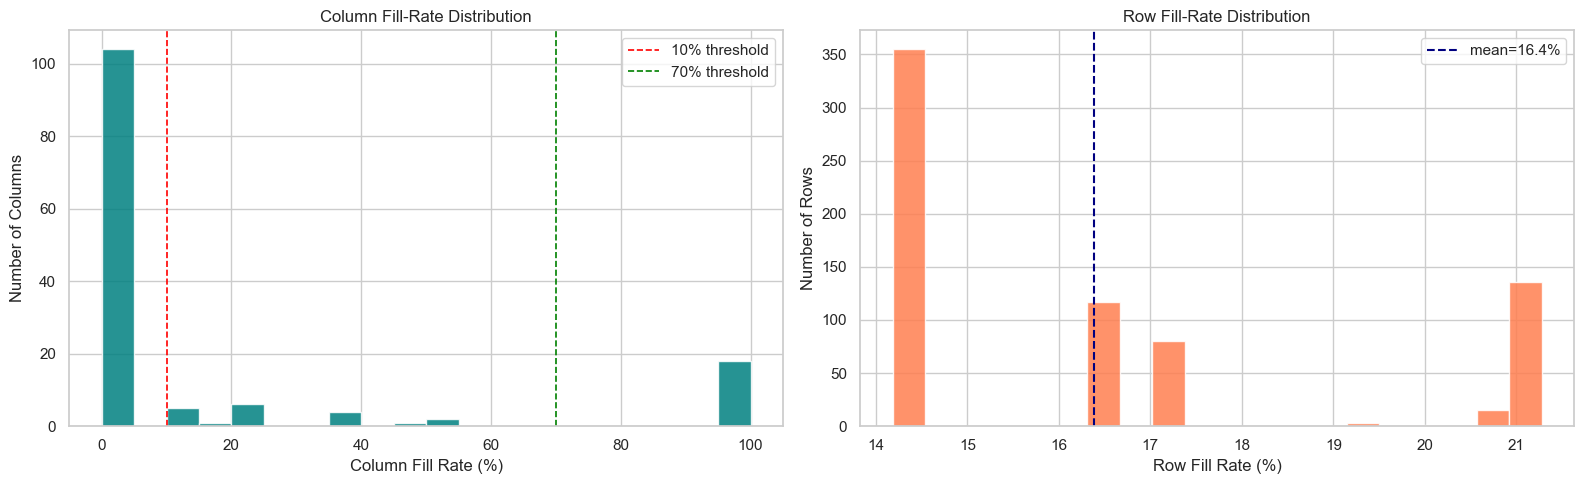

Plot saved: sparsity_analysis.png


In [23]:
# Sparsity visualization: column fill-rate distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of column fill %
axes[0].hist(col_fill, bins=20, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(10, color='red',    linestyle='--', linewidth=1.2, label='10% threshold')
axes[0].axvline(70, color='green',  linestyle='--', linewidth=1.2, label='70% threshold')
axes[0].set_xlabel('Column Fill Rate (%)')
axes[0].set_ylabel('Number of Columns')
axes[0].set_title('Column Fill-Rate Distribution')
axes[0].legend()

# Row fill % histogram
axes[1].hist(row_fill, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(row_fill.mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'mean={row_fill.mean():.1f}%')
axes[1].set_xlabel('Row Fill Rate (%)')
axes[1].set_ylabel('Number of Rows')
axes[1].set_title('Row Fill-Rate Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('sparsity_analysis.png', bbox_inches='tight', dpi=100)
plt.show()
print("Plot saved: sparsity_analysis.png")

---
## Section 8 — Column Name / Schema Analysis

Detect similar column names, naming inconsistencies, abbreviations, and schema standardization opportunities.

In [24]:
section_header("SECTION 8: COLUMN NAME / SCHEMA ANALYSIS")

cols_lower = {c: c.lower().replace('-','_').replace(' ','_') for c in df.columns}

# Naming style breakdown
has_upper      = [c for c in df.columns if any(ch.isupper() for ch in c)]
has_space      = [c for c in df.columns if ' ' in c]
has_hyphen     = [c for c in df.columns if '-' in c]
all_lower_us   = [c for c in df.columns if c == c.lower() and '_' in c and ' ' not in c]
camel_case     = [c for c in df.columns if c != c.lower() and c != c.upper() and '_' not in c]

print("  Naming style breakdown:")
print(f"    Contains uppercase letters : {len(has_upper)}")
print(f"    Contains spaces            : {len(has_space)}")
print(f"    Contains hyphens           : {len(has_hyphen)}")
print(f"    snake_case (ideal)         : {len(all_lower_us)}")
print(f"    camelCase / PascalCase     : {len(camel_case)}")

# Group columns by semantic keywords
SEMANTIC_GROUPS = {
    'age':        ['age'],
    'sex/gender': ['sex','gender'],
    'disease':    ['disease','diagnosis','diag'],
    'treatment':  ['treatment','therapy','drug','chemo','radiation','xrt','rad'],
    'survival':   ['survival','os','pfs','dfs','rfs','status','vital'],
    'tissue':     ['tissue','site','location','body'],
    'race':       ['race','ethnicity','ethnic'],
    'stage':      ['stage','grade'],
    'study':      ['study','project','cohort','source','dataset'],
    'sample':     ['sample','specimen','material'],
}

print("\n  Semantic column grouping:")
for group, keywords in SEMANTIC_GROUPS.items():
    matches = [c for c in df.columns if any(kw in c.lower() for kw in keywords)]
    if matches:
        print(f"\n    [{group}] ({len(matches)} columns):")
        for m in matches[:10]:
            print(f"        {m}")


  SECTION 8: COLUMN NAME / SCHEMA ANALYSIS
  Naming style breakdown:
    Contains uppercase letters : 24
    Contains spaces            : 0
    Contains hyphens           : 0
    snake_case (ideal)         : 71
    camelCase / PascalCase     : 2

  Semantic column grouping:

    [age] (7 columns):
        age
        infant_age
        age_category
        gestational_age
        disease_stage
        age_seroconversion
        age_T1D_diagnosis

    [sex/gender] (1 columns):
        gender

    [disease] (5 columns):
        disease
        disease_subtype
        disease_stage
        disease_location
        age_T1D_diagnosis

    [treatment] (2 columns):
        treatment
        previous_therapy

    [survival] (8 columns):
        menopausal_status
        glucose
        autoantibody_positive
        age_T1D_diagnosis
        performance_status
        PFS12
        fasting_glucose
        zigosity

    [tissue] (6 columns):
        body_site
        location
        body_subsi

In [25]:
# Detect abbreviation-like columns (short, uppercase)
abbrev_cols = [c for c in df.columns if len(c) <= 4 and c == c.upper() and c.isalpha()]
print("  Abbreviation-like column names (<=4 chars, all caps):")
for c in abbrev_cols:
    print(f"    '{c}'  -> {df[c].dropna().unique()[:5]}")

# Token-based similarity: find columns whose names share majority of tokens
print("\n  Similar column name pairs (shared word stems):")

def tokenize(name):
    import re
    return set(re.split(r'[_\-\s]+', name.lower()))

similar_pairs = []
col_list = df.columns.tolist()
for i, a in enumerate(col_list):
    for b in col_list[i+1:]:
        ta, tb = tokenize(a), tokenize(b)
        if len(ta) == 0 or len(tb) == 0:
            continue
        jaccard = len(ta & tb) / len(ta | tb)
        if jaccard > 0.4 and (ta & tb) - {'the','a','of','in','and','or','for'}:
            similar_pairs.append((jaccard, a, b))

similar_pairs.sort(reverse=True)
for score, a, b in similar_pairs[:20]:
    print(f"    {score:.2f}  '{a}'  <->  '{b}'")

  Abbreviation-like column names (<=4 chars, all caps):
    'PMID'  -> [30459201 30567928 30001517]
    'BMI'  -> [31.62627648 31.67346939 25.21625331 28.71972318 27.33564014]
    'ESR'  -> []
    'ORR'  -> []
    'HBI'  -> []
    'HLA'  -> []
    'LDL'  -> []
    'ALT'  -> []

  Similar column name pairs (shared word stems):
    1.00  'ldl'  <->  'LDL'
    1.00  'hscrp'  <->  'hsCRP'
    1.00  'alt'  <->  'ALT'
    0.50  'smoker'  <->  'ever_smoker'
    0.50  'minimum_read_length'  <->  'median_read_length'
    0.50  'location'  <->  'disease_location'
    0.50  'glucose'  <->  'fasting_glucose'
    0.50  'family'  <->  'family_role'
    0.50  'family'  <->  'antibiotics_family'
    0.50  'disease'  <->  'disease_subtype'
    0.50  'disease'  <->  'disease_stage'
    0.50  'disease'  <->  'disease_location'
    0.50  'alcohol'  <->  'alcohol_numeric'
    0.50  'age'  <->  'infant_age'
    0.50  'age'  <->  'gestational_age'
    0.50  'age'  <->  'age_seroconversion'
    0.50  'age'  <

---
## Section 9 — Value Standardization Analysis

Case inconsistencies, abbreviations, synonyms, free-text entries, and ontology mapping opportunities.

In [29]:
# Ontology mapping opportunities: columns whose values look like codes
print("  Columns with code-like values (NCIT, UBERON, numeric codes):")
import re
code_pattern = re.compile(r'^(C\d{4,}|UBERON:\d+|GO:\d+|HP:\d+|\d{3,})$', re.IGNORECASE)

for col in cat_df.columns:
    series = cat_df[col].dropna()
    if len(series) < 3:
        continue
    code_like = series.apply(lambda v: bool(code_pattern.match(str(v).strip()))).mean()
    if code_like > 0.3:
        print(f"    '{col}': {code_like*100:.0f}% code-like values  — e.g. {series.unique()[:5].tolist()}")

# Abbreviation detection: common medical abbreviations in values
MEDICAL_ABBREVS = {
    'sex': {'M': 'Male', 'F': 'Female', 'U': 'Unknown'},
    'race': {'AA': 'African American', 'W': 'White', 'A': 'Asian'},
    'treatment': {'XRT': 'Radiation', 'RT': 'Radiation', 'CTX': 'Chemotherapy',
                  'TMZ': 'Temozolomide', 'Rad': 'Radiation'},
}

print("\n  Known medical abbreviations detected in columns:")
for col in cat_df.columns:
    series = cat_df[col].dropna()
    for group, abbrevs in MEDICAL_ABBREVS.items():
        found = [k for k in abbrevs if k in series.values]
        if found:
            print(f"    '{col}' [{group}]: {found} -> {[abbrevs[k] for k in found]}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1868195450.py, line 34)


  SECTION 9: VALUE STANDARDIZATION ANALYSIS
  Case inconsistency per column (unique raw vs. after lower+strip):
  No case inconsistencies detected.

  Potential free-text columns (high cardinality >30% of rows):
    'sample_id': 707 unique / 707 non-null  (100%)  avg_len=18
    'subject_id': 516 unique / 707 non-null  (73%)  avg_len=13
    'NCBI_accession': 352 unique / 352 non-null  (100%)  avg_len=10


---
## Section 10 — Column Importance / Usability

Classify columns as highly usable, partially usable, or unusable for schema harmonization.

In [ ]:
section_header("SECTION 10: COLUMN IMPORTANCE / USABILITY")

fill_pct   = (df.notna().sum() / len(df) * 100)
variance   = {}
for col in df.columns:
    series = df[col].dropna()
    if series.dtype in ['float64','int64']:
        variance[col] = series.std()
    else:
        # Use normalized entropy as "variance" for categoricals
        vc = series.value_counts(normalize=True)
        entropy = -(vc * np.log2(vc + 1e-9)).sum()
        variance[col] = entropy

usability = []
for col in df.columns:
    fp   = fill_pct[col]
    var  = variance.get(col, 0)
    nu   = df[col].nunique(dropna=True)

    if fp < 5 or nu <= 1:
        tier = 'UNUSABLE'
    elif fp < 30 or (nu == 1 and fp > 0):
        tier = 'LOW'
    elif fp < 70:
        tier = 'MODERATE'
    else:
        tier = 'HIGH'

    usability.append({
        'column': col,
        'fill_%': round(fp, 1),
        'unique_vals': nu,
        'variance/entropy': round(var, 3),
        'usability_tier': tier
    })

usability_df = pd.DataFrame(usability)

for tier in ['HIGH','MODERATE','LOW','UNUSABLE']:
    subset = usability_df[usability_df['usability_tier'] == tier]
    print(f"\n  {tier} usability: {len(subset)} columns")
    print(subset[['column','fill_%','unique_vals']].head(10).to_string(index=False))

---
## Section 11 — Relationship Analysis

Numeric correlations, categorical associations (Cramér's V), feature clustering, and attribute co-occurrence.

In [ ]:
section_header("SECTION 11: RELATIONSHIP ANALYSIS")

# --- Numeric correlation ---
num_df = df.select_dtypes(include=['int64','float64'])
dense_num = num_df.loc[:, num_df.notna().mean() > 0.3]  # only columns >30% filled

if dense_num.shape[1] >= 2:
    corr = dense_num.corr()
    # Find highly correlated pairs
    print("  Highly correlated numeric pairs (|r| > 0.5):")
    pairs_found = 0
    for i, j in combinations(corr.columns, 2):
        r = corr.loc[i, j]
        if abs(r) > 0.5:
            print(f"    {i} <-> {j}  r={r:.3f}")
            pairs_found += 1
    if pairs_found == 0:
        print("    None found.")
else:
    print("  Not enough dense numeric columns for correlation analysis.")
    corr = None

# --- Cramér's V for categoricals ---
def cramers_v(x, y):
    """Cramér's V statistic for two categorical columns."""
    from scipy.stats import chi2_contingency
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    denom = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

cat_df = df.select_dtypes(include=['object'])
dense_cat = cat_df.loc[:, (cat_df.notna().mean() > 0.3) & (cat_df.nunique() <= 30) & (cat_df.nunique() >= 2)]
dense_cat_cols = dense_cat.columns.tolist()[:15]  # limit to 15 for speed

print(f"\n  Cramér's V for top categorical columns (n={len(dense_cat_cols)}):")
if len(dense_cat_cols) >= 2:
    cramer_pairs = []
    for i, j in combinations(dense_cat_cols, 2):
        v = cramers_v(df[i].fillna('__NA__'), df[j].fillna('__NA__'))
        if not np.isnan(v) and v > 0.3:
            cramer_pairs.append((v, i, j))
    cramer_pairs.sort(reverse=True)
    for v, i, j in cramer_pairs[:15]:
        print(f"    {i} <-> {j}  V={v:.3f}")
    if not cramer_pairs:
        print("    No pairs with V > 0.3 found.")

In [34]:
# Co-occurrence: which columns tend to be filled together
print("  Column co-occurrence (filled at same time — top 15 pairs):")
fill_matrix = df.notna().astype(int)
cooccur_pairs = []
cols_filled = [c for c in df.columns if df[c].notna().mean() > 0.05]

for i, j in combinations(cols_filled[:60], 2):   # limit to 60 cols for speed
    both = (fill_matrix[i] + fill_matrix[j] == 2).sum()
    expected = fill_matrix[i].sum() * fill_matrix[j].sum() / len(df)
    lift = both / (expected + 1e-9)
    if lift > 2:
        cooccur_pairs.append((lift, i, j, both))

cooccur_pairs.sort(reverse=True)
for lift, i, j, both in cooccur_pairs[:15]:
    print(f"    lift={lift:.2f}  '{i}' & '{j}'  (co-filled {both} times)")

  Column co-occurrence (filled at same time — top 15 pairs):
    lift=8.73  'location' & 'fobt'  (co-filled 81 times)
    lift=8.73  'antibiotics_current_use' & 'location'  (co-filled 81 times)
    lift=8.73  'antibiotics_current_use' & 'fobt'  (co-filled 81 times)
    lift=8.73  'antibiotics_current_use' & 'age'  (co-filled 81 times)
    lift=8.73  'age' & 'location'  (co-filled 81 times)
    lift=8.73  'age' & 'fobt'  (co-filled 81 times)
    lift=8.73  'antibiotics_current_use' & 'BMI'  (co-filled 80 times)
    lift=8.73  'age' & 'BMI'  (co-filled 80 times)
    lift=8.73  'BMI' & 'location'  (co-filled 80 times)
    lift=8.73  'BMI' & 'fobt'  (co-filled 80 times)
    lift=4.68  'feeding_practice' & 'breastfeeding_duration'  (co-filled 136 times)
    lift=4.65  'feeding_practice' & 'formula_first_day'  (co-filled 151 times)
    lift=4.65  'breastfeeding_duration' & 'formula_first_day'  (co-filled 136 times)
    lift=4.56  'infant_age' & 'gestational_age'  (co-filled 155 times)
    li


  SECTION 12: VISUALIZATION SUITE


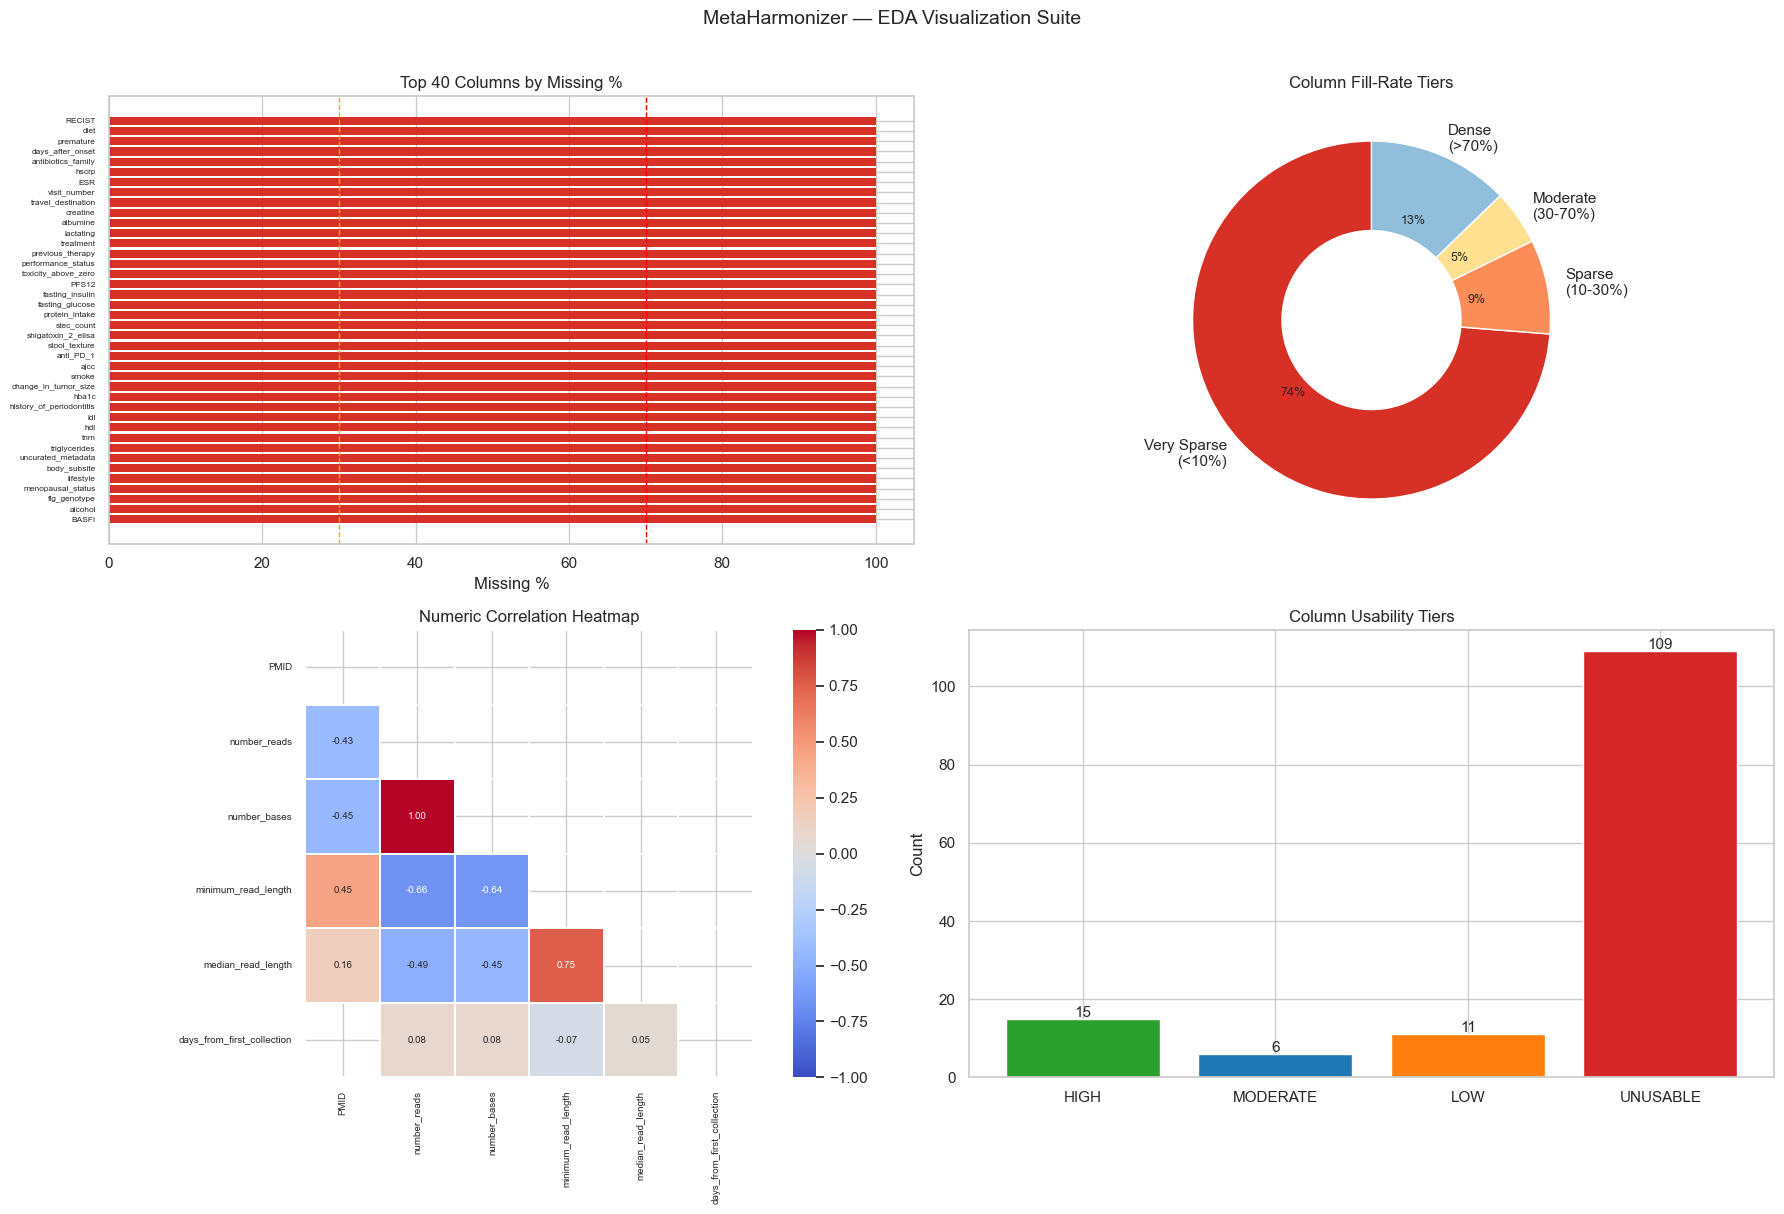

Plot saved: eda_visualization_suite.png


In [35]:
section_header("SECTION 12: VISUALIZATION SUITE")

# --- Plot 1: Comprehensive missing value summary ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('MetaHarmonizer — EDA Visualization Suite', fontsize=14, y=1.01)

# 1a: Missing % per column (top 40)
miss_sorted = miss_df.head(40)
colors12 = ['#d73027' if p > 70 else '#fdae61' if p > 30 else '#fee090'
            for p in miss_sorted['missing_pct']]
axes[0, 0].barh(miss_sorted['column'][::-1], miss_sorted['missing_pct'][::-1],
                color=colors12[::-1], edgecolor='none')
axes[0, 0].axvline(70, color='red', linestyle='--', linewidth=1)
axes[0, 0].axvline(30, color='orange', linestyle='--', linewidth=1)
axes[0, 0].set_title('Top 40 Columns by Missing %')
axes[0, 0].set_xlabel('Missing %')
axes[0, 0].tick_params(axis='y', labelsize=6)

# 1b: Column fill-tier donut
labels = ['Very Sparse\n(<10%)', 'Sparse\n(10-30%)', 'Moderate\n(30-70%)', 'Dense\n(>70%)']
sizes  = [
    (col_fill < 10).sum(),
    ((col_fill >= 10) & (col_fill < 30)).sum(),
    ((col_fill >= 30) & (col_fill < 70)).sum(),
    (col_fill >= 70).sum()
]
wedge_colors = ['#d73027','#fc8d59','#fee090','#91bfdb']
wedges, texts, autotexts = axes[0, 1].pie(
    sizes, labels=labels, autopct='%1.0f%%',
    colors=wedge_colors, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white')
)
for t in autotexts:
    t.set_fontsize(9)
axes[0, 1].set_title('Column Fill-Rate Tiers')

# 1c: Numeric correlation heatmap
num_df_plot = df.select_dtypes(include=['float64','int64'])
dense_num_plot = num_df_plot.loc[:, num_df_plot.notna().mean() > 0.3]
if dense_num_plot.shape[1] >= 2:
    corr_plot = dense_num_plot.corr()
    mask = np.triu(np.ones_like(corr_plot, dtype=bool))
    sns.heatmap(
        corr_plot, mask=mask, ax=axes[1, 0],
        cmap='coolwarm', vmin=-1, vmax=1,
        annot=dense_num_plot.shape[1] <= 12,
        fmt='.2f', linewidths=0.3, square=True,
        annot_kws={'size': 7}
    )
    axes[1, 0].set_title('Numeric Correlation Heatmap')
    axes[1, 0].tick_params(labelsize=7)
else:
    axes[1, 0].text(0.5, 0.5, 'Not enough dense numeric cols', ha='center', va='center')
    axes[1, 0].set_title('Numeric Correlation Heatmap')

# 1d: Usability tier bar chart
tier_counts = usability_df['usability_tier'].value_counts().reindex(
    ['HIGH','MODERATE','LOW','UNUSABLE'], fill_value=0)
tier_colors = ['#2ca02c','#1f77b4','#ff7f0e','#d62728']
axes[1, 1].bar(tier_counts.index, tier_counts.values, color=tier_colors, edgecolor='white')
for i, (label, val) in enumerate(tier_counts.items()):
    axes[1, 1].text(i, val + 0.5, str(val), ha='center', fontsize=11)
axes[1, 1].set_title('Column Usability Tiers')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_visualization_suite.png', bbox_inches='tight', dpi=120)
plt.show()
print("Plot saved: eda_visualization_suite.png")

---
## Export Summary Results

In [ ]:
section_header("HARMONIZATION: COLUMN NAME SIMILARITY DETECTION")
import difflib, re
from collections import defaultdict

# ── 1. Semantic token normalizer ─────────────────────────────────────────────
SYNONYM_MAP = {
    "age": "AGE", "years": "AGE", "yr": "AGE", "yrs": "AGE",
    "diagnosis": "DIAGNOSIS", "dx": "DIAGNOSIS", "diag": "DIAGNOSIS",
    "disease": "DIAGNOSIS", "condition": "DIAGNOSIS", "disorder": "DIAGNOSIS",
    "sample": "SAMPLE", "specimen": "SAMPLE",
    "subject": "SUBJECT", "patient": "SUBJECT", "participant": "SUBJECT",
    "individual": "SUBJECT",
    "treatment": "TREATMENT", "therapy": "TREATMENT", "drug": "TREATMENT",
    "tx": "TREATMENT",
    "vital": "OUTCOME", "status": "OUTCOME", "death": "OUTCOME",
    "os": "OUTCOME", "pfs": "OUTCOME", "survival": "OUTCOME",
    "stage": "STAGE", "grade": "STAGE", "severity": "STAGE",
    "tissue": "TISSUE", "site": "TISSUE", "body": "TISSUE",
    "location": "TISSUE",
    "sex": "SEX", "gender": "SEX",
    "race": "RACE", "ethnicity": "RACE", "ethnic": "RACE",
    "time": "TIME", "date": "TIME", "day": "TIME",
    "days": "TIME", "duration": "TIME", "onset": "TIME",
    "study": "STUDY", "project": "STUDY", "cohort": "STUDY",
}

def split_tokens(name):
    parts = re.split(r"[_\-\s]+", name.lower())
    expanded = []
    for p in parts:
        subs = re.sub(r"([a-z])([A-Z])", r"\1 \2", p).split()
        expanded.extend([s.lower() for s in subs])
    return [t for t in expanded if t]

def normalize_tokens(name):
    return set(SYNONYM_MAP.get(t, t) for t in split_tokens(name))

# ── 2. Combined similarity score ─────────────────────────────────────────────
def col_similarity(a, b):
    ta, tb = normalize_tokens(a), normalize_tokens(b)
    if not ta or not tb:
        return 0.0
    jaccard   = len(ta & tb) / len(ta | tb)
    seq_ratio = difflib.SequenceMatcher(None, a.lower(), b.lower()).ratio()
    return round(0.6 * jaccard + 0.4 * seq_ratio, 3)

# ── 3. Within raw-dataset similarity ─────────────────────────────────────────
print("  [A] Within raw dataset  (threshold >= 0.40):")
raw_cols = df.columns.tolist()
sim_pairs = []
for i in range(len(raw_cols)):
    for j in range(i + 1, len(raw_cols)):
        score = col_similarity(raw_cols[i], raw_cols[j])
        if score >= 0.40:
            sim_pairs.append({
                "col_A": raw_cols[i], "col_B": raw_cols[j],
                "similarity": score,
                "concepts_A": str(sorted(normalize_tokens(raw_cols[i]))),
                "concepts_B": str(sorted(normalize_tokens(raw_cols[j]))),
            })

sim_df = (pd.DataFrame(sim_pairs)
            .sort_values("similarity", ascending=False)
            .reset_index(drop=True))
print(f"  {len(sim_df)} pairs found\n")
if len(sim_df):
    print(sim_df[["col_A", "col_B", "similarity"]].head(25).to_string(index=False))

# ── 4. Cross-dataset: raw columns vs curated schema ──────────────────────────
print("\n  [B] Cross-dataset raw vs curated  (threshold >= 0.45):")
cur_cols = df_curated.columns.tolist()
cross_pairs = []
for rc in raw_cols:
    for cc in cur_cols:
        score = col_similarity(rc, cc)
        if score >= 0.45:
            cross_pairs.append({
                "raw_col": rc, "curated_col": cc,
                "similarity": score,
                "raw_concepts":     str(sorted(normalize_tokens(rc))),
                "curated_concepts": str(sorted(normalize_tokens(cc))),
            })

cross_df = (pd.DataFrame(cross_pairs)
              .sort_values("similarity", ascending=False)
              .reset_index(drop=True)
            if cross_pairs else pd.DataFrame())
if len(cross_df):
    print(f"  {len(cross_df)} cross-pairs found (top 25 shown):\n")
    print(cross_df[["raw_col", "curated_col", "similarity"]].head(25).to_string(index=False))
else:
    print("  No cross-pairs above threshold.")

# ── 5. Union-Find clustering of raw columns ───────────────────────────────────
parent = {c: c for c in raw_cols}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    parent[find(a)] = find(b)

for _, row in sim_df.iterrows():
    union(row["col_A"], row["col_B"])

clusters = defaultdict(list)
for col in raw_cols:
    clusters[find(col)].append(col)
multi = sorted([v for v in clusters.values() if len(v) > 1], key=lambda x: -len(x))

print(f"\n  Similarity clusters in raw dataset: {len(multi)} groups")
for i, members in enumerate(multi, 1):
    print(f"\n  Cluster {i}  ({len(members)} columns):")
    for m in sorted(members):
        print(f"    {m:45s}  -> {sorted(normalize_tokens(m))}")

# ── 6. Save CSVs ──────────────────────────────────────────────────────────────
sim_df.to_csv("eda_column_similarity.csv", index=False)
if len(cross_df):
    cross_df.to_csv("eda_cross_schema_similarity.csv", index=False)
    print("\n  Saved: eda_column_similarity.csv + eda_cross_schema_similarity.csv")
else:
    print("\n  Saved: eda_column_similarity.csv")

# ── 7. Bar chart — top similar pairs ─────────────────────────────────────────
if len(sim_df) > 0:
    top_n   = min(25, len(sim_df))
    plot_df = sim_df.head(top_n).copy()
    plot_df["pair"] = plot_df["col_A"] + "  <->  " + plot_df["col_B"]
    bar_colors = [
        "#d73027" if s >= 0.8 else "#fc8d59" if s >= 0.6 else "#fee08b"
        for s in plot_df["similarity"][::-1]
    ]
    fig, ax = plt.subplots(figsize=(14, max(5, top_n * 0.5)))
    ax.barh(plot_df["pair"][::-1], plot_df["similarity"][::-1],
            color=bar_colors, edgecolor="none")
    ax.axvline(0.8, color="red",    linestyle="--", linewidth=1.2, label="High (>=0.8)")
    ax.axvline(0.6, color="orange", linestyle="--", linewidth=1.2, label="Medium (>=0.6)")
    ax.set_xlabel("Combined Similarity Score  (60% semantic-Jaccard + 40% SequenceMatcher)")
    ax.set_title("Column Name Similarity — Harmonization Candidates",
                 fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.savefig("harmonization_similarity.png", bbox_inches="tight", dpi=120)
    plt.show()
    print("Plot saved: harmonization_similarity.png")
else:
    print("\n  No similar column pairs found above threshold.")
